In [5]:
import kwant
import tinyarray as ta
import numpy as np
import types
import matplotlib.pyplot as plt

In [6]:
from pathlib import Path
Path('zad_2').mkdir(exist_ok=True)

In [20]:
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"""
\usepackage[T1]{fontenc}
\usepackage[utf8]{inputenc}
\usepackage[polish]{babel}
\usepackage{lmodern}
\usepackage{amsmath}
\usepackage{amssymb}
\usepackage{physics}
"""

plt.rcParams.update({
    # ===== Font =====
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # ===== Sizes =====
    "font.size": 16,
    "axes.labelsize": 22,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,

    # ===== Lines =====
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.5,

    # ===== Ticks =====
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # ===== Figure =====
    "figure.figsize": (10, 7),
    "figure.dpi": 300,

    # ===== Save =====
    "savefig.dpi": 300,
    "savefig.bbox": "tight",

    # ===== Legend =====
    "legend.frameon": False,
    "legend.fancybox": False,
})

In [8]:
# Konwersja jednostek
def eV_to_au(e):   
    return e * 0.03674932587122423

def nm_to_au(x):   
    return x * 18.89726133921252

def T_to_au(b):    
    return b * 4.254382e-6

MU_B = 0.5   # magneton Bohra w j.a.

# Macierze Pauliego 
sx = ta.array([[ 0 , 1 ], 
               [ 1 , 0 ]])

sy = ta.array([[ 0 ,-1j], 
               [ 1j, 0 ]])

sz = ta.array([[ 1 , 0 ], 
               [ 0 ,-1 ]])

# Macierz do rozróżnienia orbitali w kontakcie 
conservation_law_matrix = ta.array([[1, 0], 
                                    [0, 2]])

## Układ

In [ ]:
def build_system(params):
    dx = params.dx
    L = params.L
    W = params.W
    m = params.m
    g = params.g
    Bx, By, Bz = params.B
    Bh = params.Bh
 
    t_hop = 1.0 / (2.0 * m * dx * dx)
 
    def B_hel(site):
        x, _ = site.pos
        phase = 2 * np.pi * (x - 0.5 * L * dx) / (L * dx)
        return Bh * np.sin(phase), 0.0, Bh * np.cos(phase)
 
    def onsite(site):
        Bhx, Bhy, Bhz = B_hel(site)
        zeeman = 0.5 * g * MU_B * (
            (Bx + Bhx) * sx +
            (By + Bhy) * sy +
            (Bz + Bhz) * sz
        )
        return ta.identity(2) * 4 * t_hop + zeeman
 
    def hop_x(si, sj):
        return -ta.identity(2) * t_hop
 
    def hop_y(si, sj):
        return -ta.identity(2) * t_hop
 
    lat = kwant.lattice.square(dx, norbs=2)
    sys = kwant.Builder()
 
    sys[(lat(i, j) for i in range(L) for j in range(W))] = onsite
    sys[kwant.builder.HoppingKind((-1,  0), lat, lat)] = hop_x
    sys[kwant.builder.HoppingKind(( 0, -1), lat, lat)] = hop_y
 
    # dolaczam lewy kontakt
    left_lead = kwant.Builder(kwant.TranslationalSymmetry((-dx, 0)))
    left_lead[(lat(i, j) for i in range(L) for j in range(W))] = onsite
    left_lead[kwant.builder.HoppingKind((-1,  0), lat, lat)] = hop_x
    left_lead[kwant.builder.HoppingKind(( 0, -1), lat, lat)] = hop_y
 
    # dolaczam prawy kontakt - jest lustrzanym odbiciem lewego
    sys.attach_lead(left_lead)
    sys.attach_lead(left_lead.reversed())
 
    return sys.finalized()

## Funkcje

In [10]:
def compute_dispersion(params, lead_idx=0, k_max=0.5, nk=201):
    sys = build_system(params)
    dx = params.dx
    momenta = np.linspace(-k_max, k_max, nk) * dx / nm_to_au(1.0)
    bands = kwant.physics.Bands(sys.leads[lead_idx])
    energies = np.array([bands(k) for k in momenta])
    return momenta / dx * nm_to_au(1.0), energies
 
def compute_conductance_vs_Bext(params, Bext_max, n_points, E):
    Bext_range = np.linspace(0.0, Bext_max, n_points)
    cond = np.zeros(n_points)
    for i, Bext in enumerate(Bext_range):
        params.B = (0, 0, T_to_au(Bext))
        sys = build_system(params)
        sm = kwant.smatrix(sys, E)
        cond[i] = sm.transmission(1, 0)
    return Bext_range, cond

## Parametry

In [11]:
dx = nm_to_au(1)
lenght = int(1000 / 1)
width = int(30 / 1)
 
params = types.SimpleNamespace(
    dx = dx,
    L = lenght,
    W = width,
    m = 0.1,
    g = 200,
    B = (0, 0, 0),
    Bh = T_to_au(0.05),
)

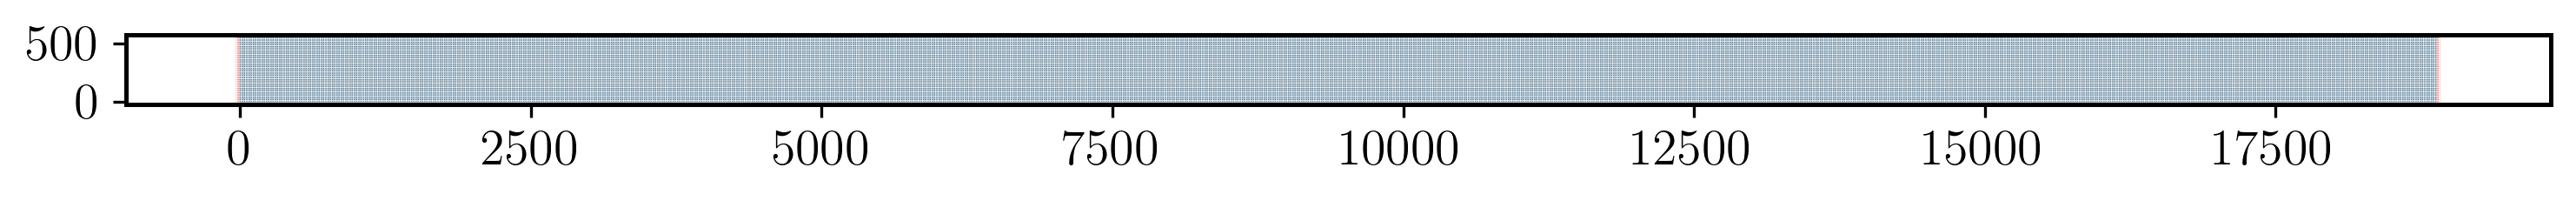

In [13]:
# wizualiuzacja układu
sys_vis = build_system(params)
kwant.plot(sys_vis, num_lead_cells=2, fig_size=(12, 4), show=False);

#### 1. obliczyć relacje dyspersji $E(k)$ w lewym kontakcie zakładając, że $B_{ext} = 0$. Powinniśmy zaobserwować rozszczepienie Zeemana pochodzące od pola helikalnego $B_h$

In [14]:
params.B = (0, 0, 0)
k_max = 0.5
E_max = 0.05
nk = 201
 
momenta, energies = compute_dispersion(params, k_max=k_max, nk=nk)

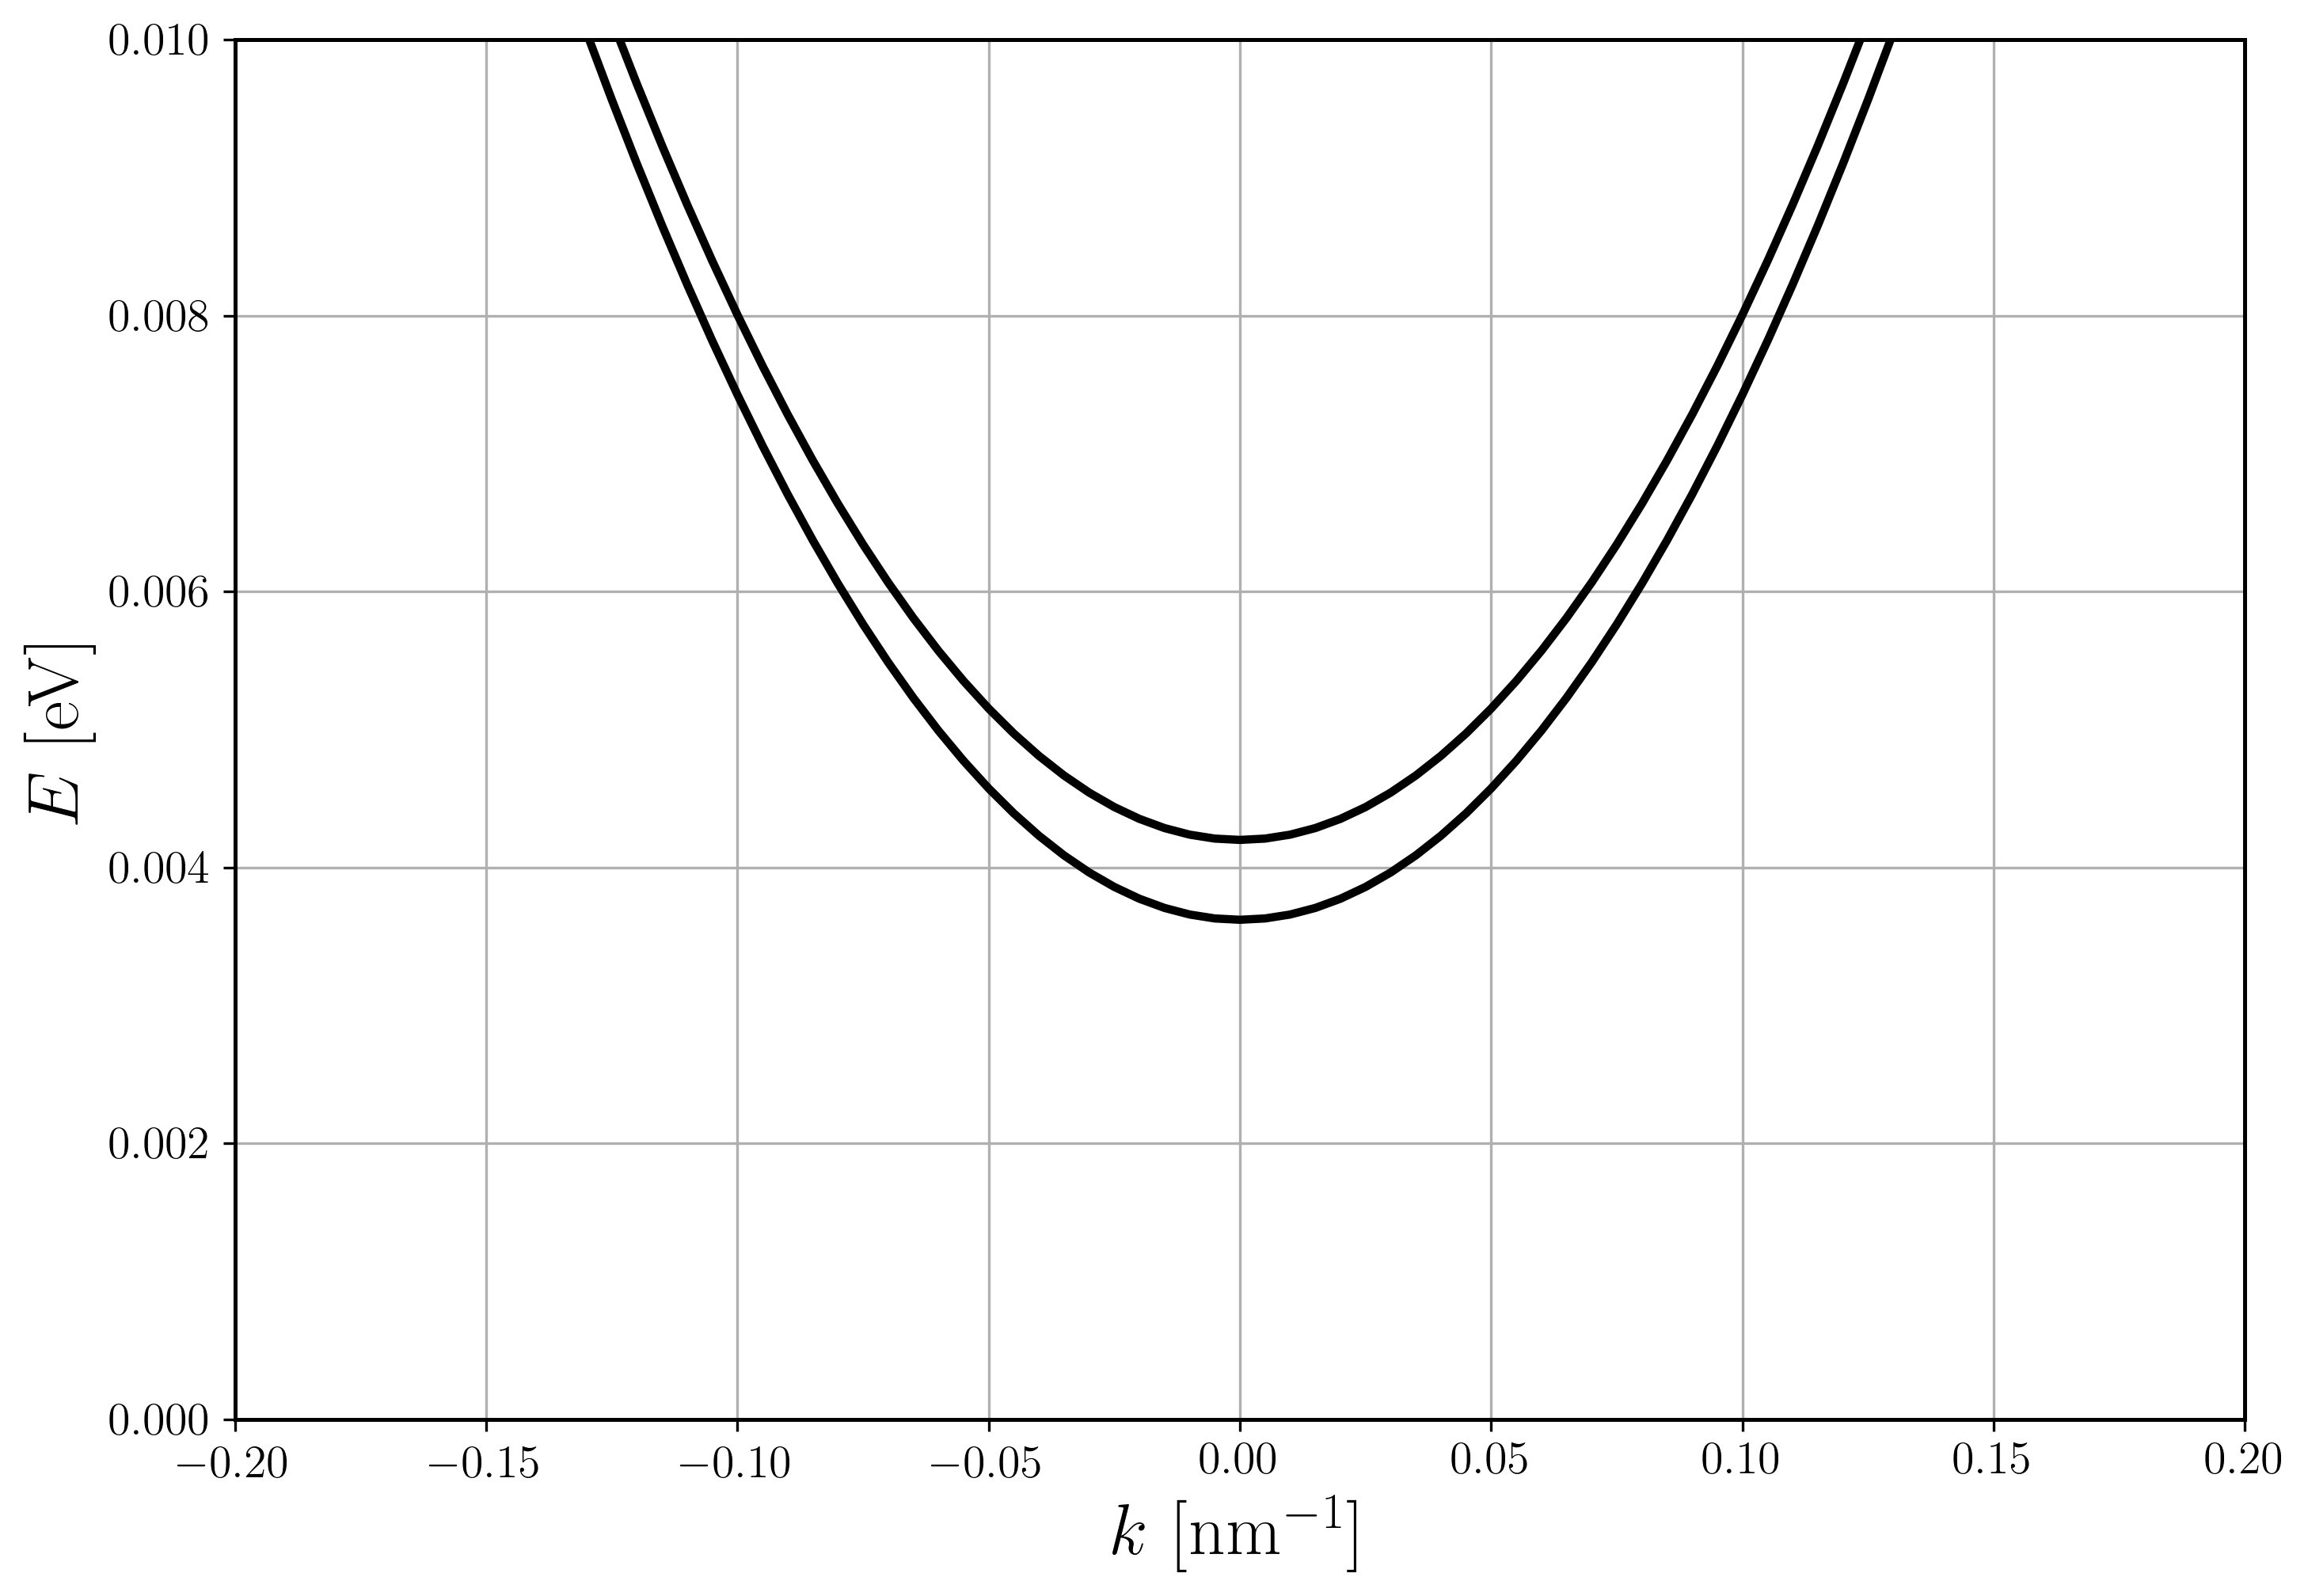

In [21]:
plt.figure()
plt.plot(momenta, np.array(energies) / eV_to_au(1.0), "k-")
plt.xlim(-k_max, k_max)
plt.ylim(0, E_max)
plt.xlabel(r"$k\ [\mathrm{nm}^{-1}]$")
plt.ylabel(r"$E\ [\mathrm{eV}]$")
plt.grid()
plt.tight_layout()
plt.savefig("zad_2/dispersion_Bh.png", dpi=150)
plt.show()

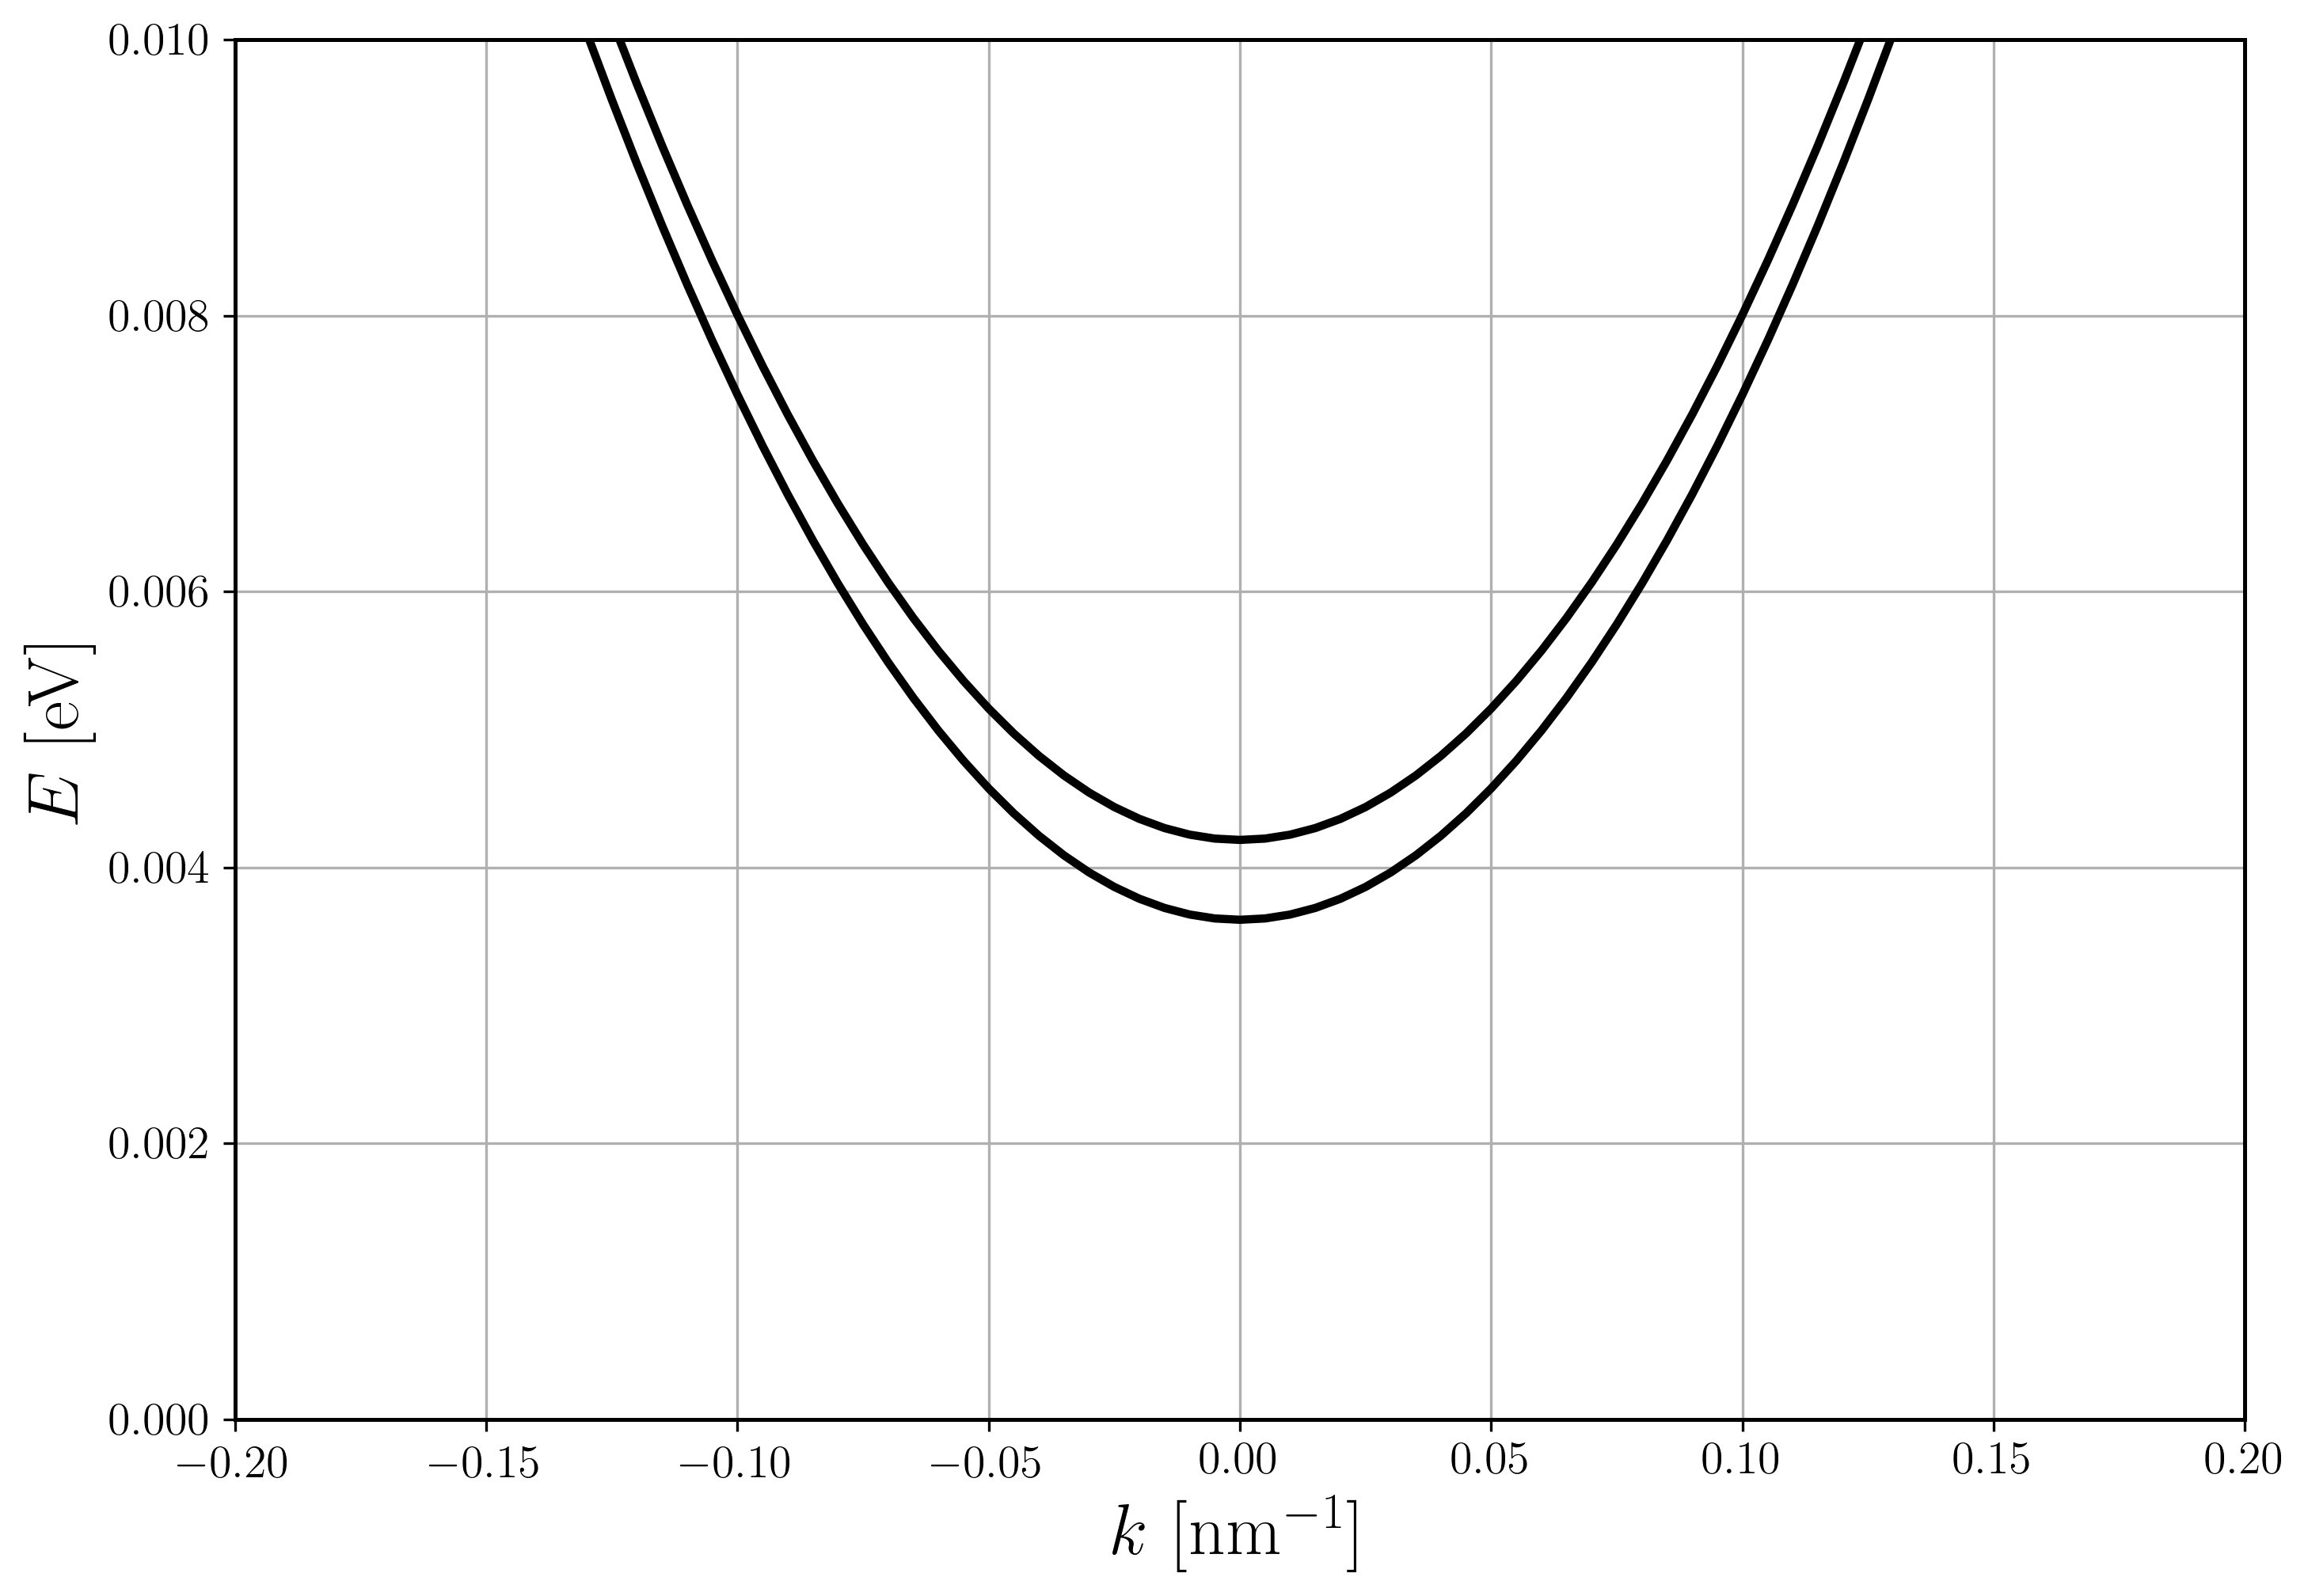

In [22]:
# zbliżenie na lukę
k_max = 0.2
E_max = 0.01
 
plt.figure()
plt.plot(momenta, np.array(energies) / eV_to_au(1.0), "k-")
plt.xlim(-k_max, k_max)
plt.ylim(0, E_max)
plt.xlabel(r"$k\ [\mathrm{nm}^{-1}]$")
plt.ylabel(r"$E\ [\mathrm{eV}]$")
plt.grid()
plt.tight_layout()
plt.savefig("zad_2/dispersion_Bh_zoom.png", dpi=150)
plt.show()

#### 2. obliczyć konduktancje w funkcji pola $B_{ext}$ w przedziale $[0, 100]$ [ mT ] zakładając, że do układu wstrzykujemy elektron o energii zlokalizowanej dokładnie w połowie spinowo rozszczepionego stanu podstawowego ($E = 3.5$ [ meV ]), związanego z kwantyzacją w kierunku poprzecznym. Podobnie jak w eksperymencie powinniśmy obserwować nagły spadek konduktancji dla $B_{ext} ≈ B_h$ .

In [17]:
params.B = (0, 0, 0)
E = eV_to_au(0.0035)
n = 201
 
Bext_range, cond = compute_conductance_vs_Bext(params, Bext_max=0.1, n_points=n, E=E)

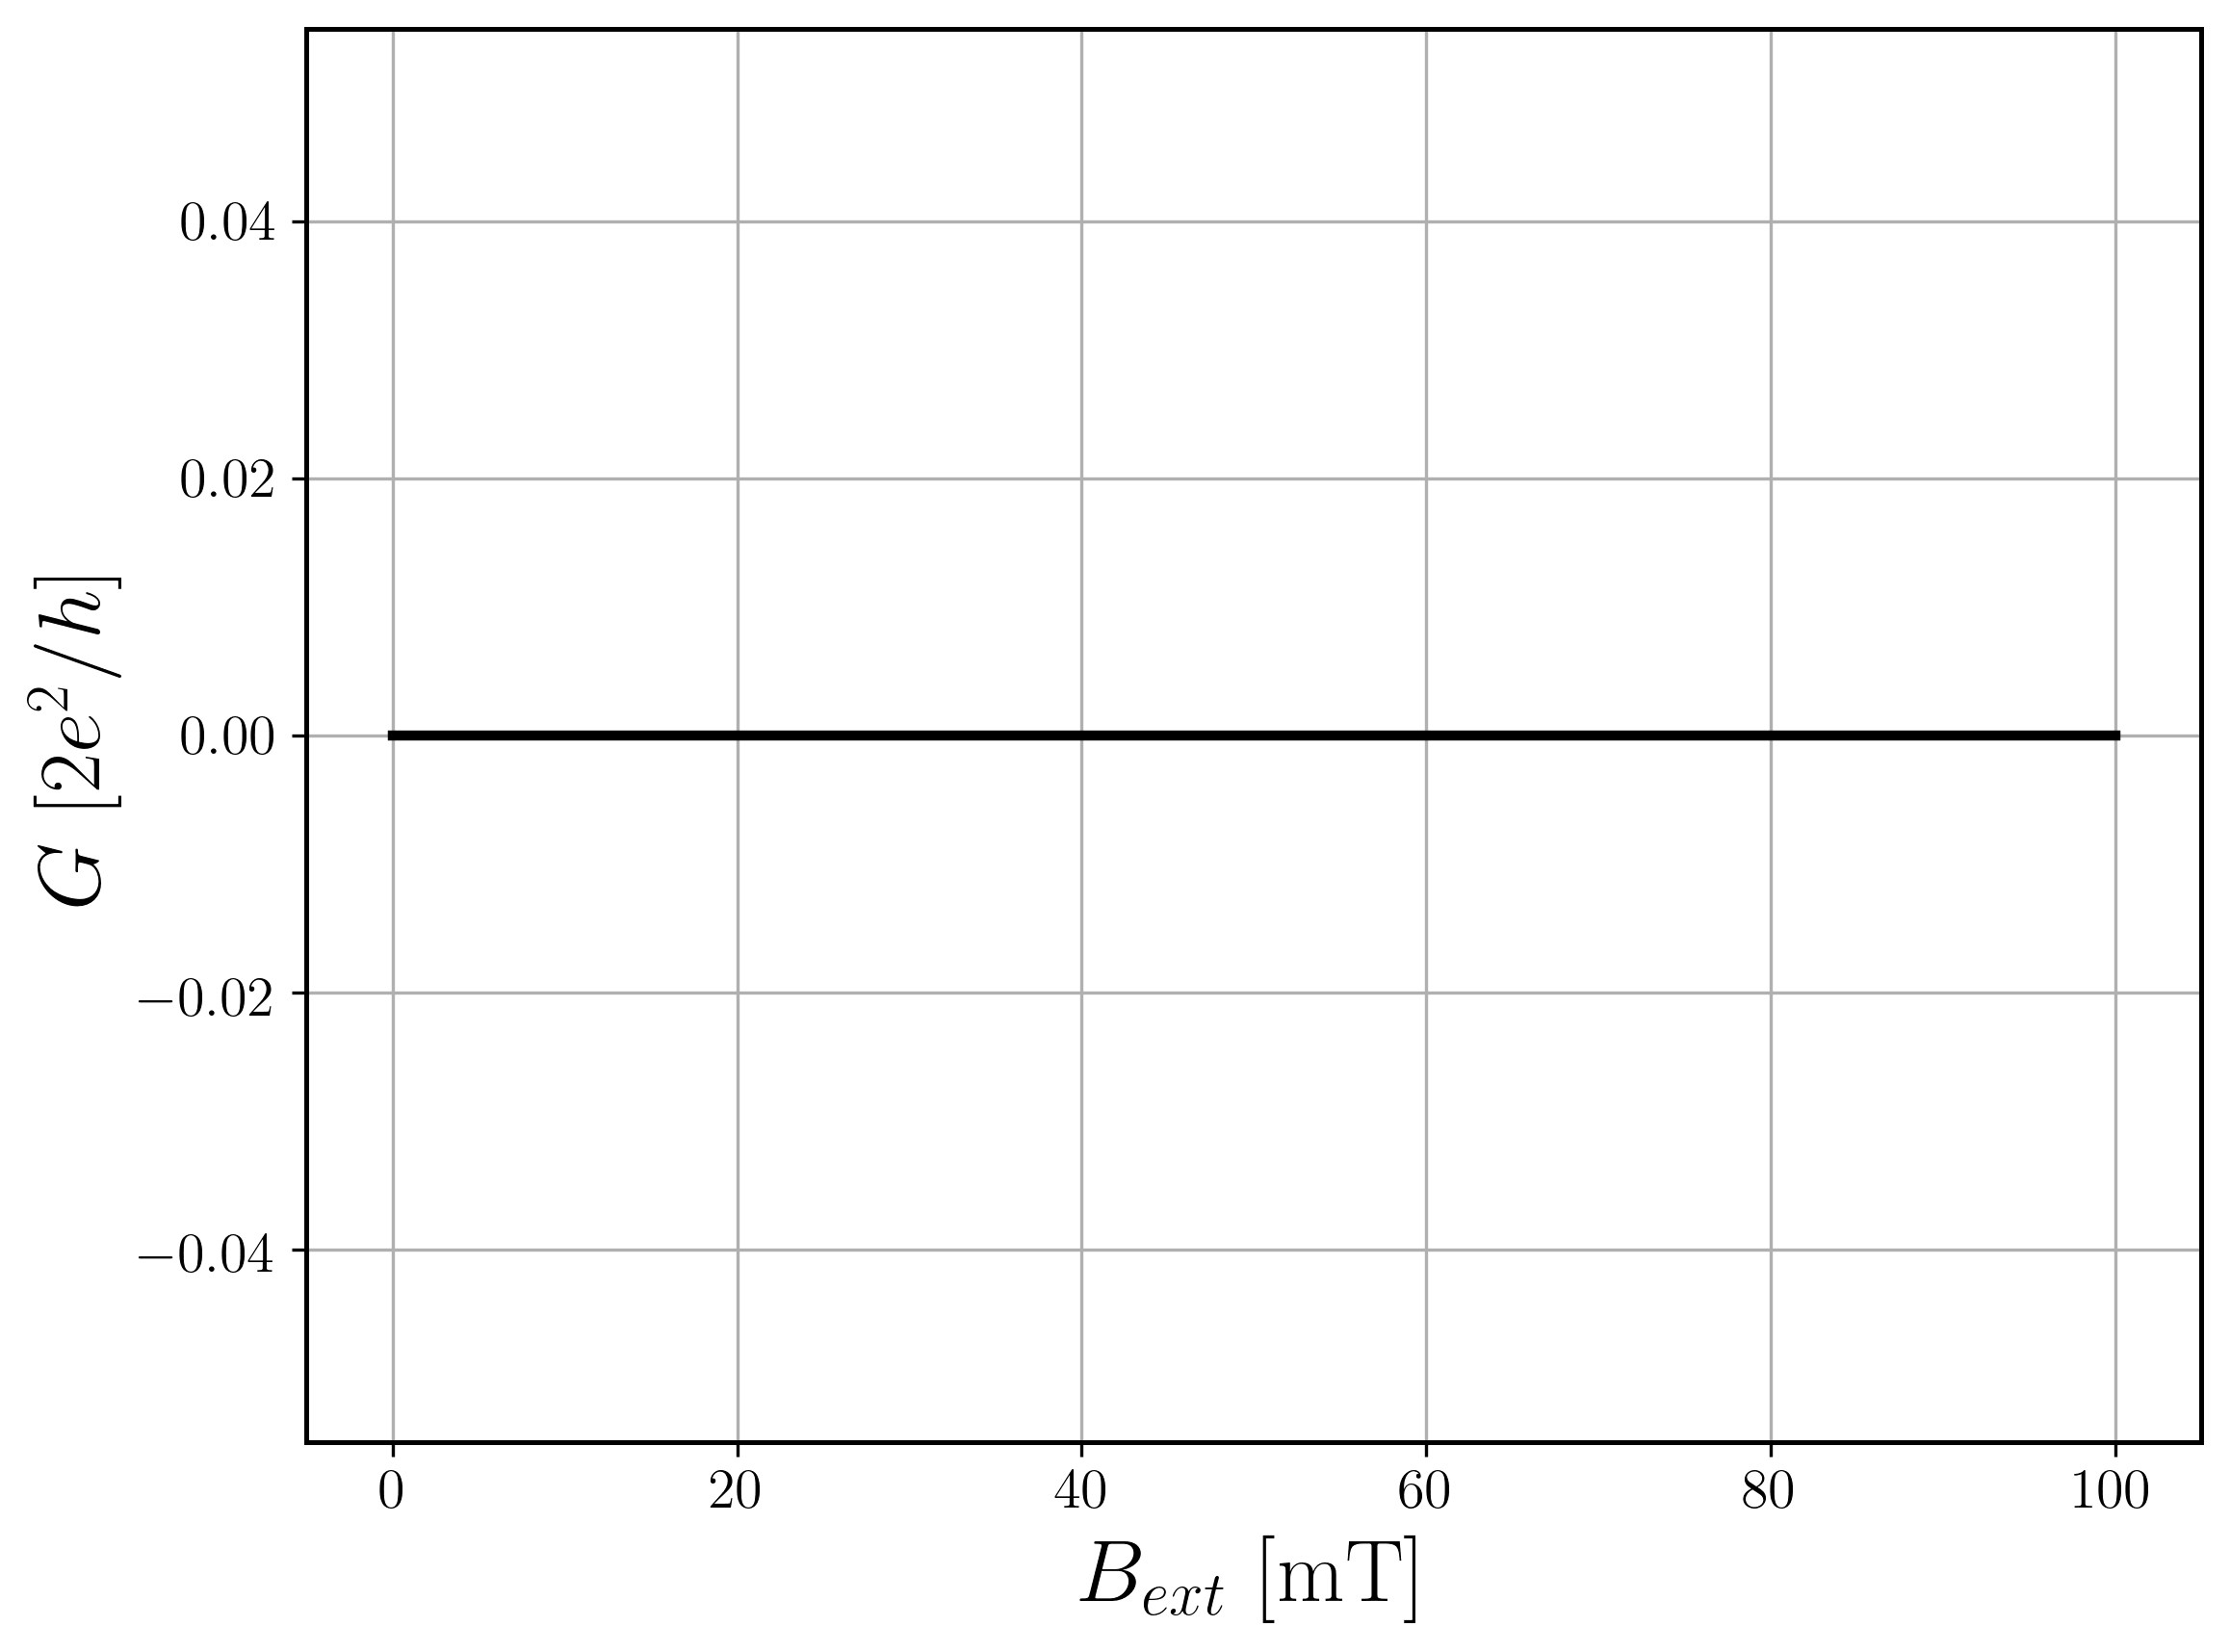

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(Bext_range * 1e3, cond, "k-")
plt.xlabel(r"$B_{ext}\ [\mathrm{mT}]$")
plt.ylabel(r"$G\ [2e^2/h]$")
plt.grid()
plt.tight_layout()
plt.savefig("zad_2/cond_Bext.png", dpi=150)
plt.show()